In [3]:
pip install pgmpy catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 64.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


import xgboost as xgb
from catboost import CatBoostClassifier


from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD

from sklearn.metrics import (
    recall_score,
    precision_score,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
train = '/content/drive/MyDrive/ADNI_DATA/clean/adni_train_preprocessed.csv'
val = '/content/drive/MyDrive/ADNI_DATA/clean/adni_val_preprocessed.csv'
test = '/content/drive/MyDrive/ADNI_DATA/clean/adni_test_preprocessed.csv'

train_df = pd.read_csv(train, low_memory=False)
val_df = pd.read_csv(val, low_memory=False)
test_df = pd.read_csv(test, low_memory=False)

In [9]:
train_df.shape

(8004, 8617)

In [10]:
val_df.shape

(1714, 8617)

In [11]:
test_df.shape

(1740, 8617)

In [13]:
train_df.info

<bound method DataFrame.info of        RID VISCODE_JOIN DX_CLEAN      SITE       AGE  PTEDUCAT     APOE4  \
0        2           bl       CN -1.203228  0.156071 -0.080650 -0.854944   
1        2          m06       CN -1.203228  0.156071 -0.080650 -0.854944   
2        2         m120       CN -1.203228  0.156071 -0.080650 -0.854944   
3        2         m132      MCI -1.203228  0.156071 -0.080650 -0.854944   
4        2         m144      MCI -1.203228  0.156071 -0.080650 -0.854944   
...    ...          ...      ...       ...       ...       ...       ...   
7999  7105           bl      MCI -0.216185  0.606454  0.722843 -0.854944   
8000  7114           bl       CN -0.267539 -1.068408  0.308645 -0.854944   
8001  7117           bl      MCI  0.534306 -0.603950  0.722843 -0.854944   
8002  7121           bl      MCI -0.216185 -1.561014  0.308645 -0.854944   
8003  7123           bl       CN -0.216185  0.986465 -0.785199 -0.854944   

         CDRSB    ADAS11    ADAS13  ...  \
0    -1.070570  0.290898  0.463905  ...   
1    -1.070570  0.290898  0.538422  ...   
2    -1.070570  0.454761  0.562223  ...   
3    -0.123577  0.454761  0.562223  ...   
4     0.640983  1.004326  1.081574  ...   
...        ...       ...       ...  ...   
7999 -0.123577  0.454761  0.698925  ...   
8000 -1.070570 -2.660909 -3.242137  ...   
8001 -0.516615 -0.719146 -0.887995  ...   
8002 -0.516615  0.832295  0.302777  ...   
8003 -1.070570  1.004326  0.677209  ...   

      update_stamp_ptd_2025-08-20T02:04:53.000000000  \
0                                                0.0   
1                                                0.0   
2                                                0.0   
3                                                0.0   
4                                                0.0   
...                                              ...   
7999                                             0.0   
8000                                             0.0   
8001                                             0.0   
8002                                             0.0   
8003                                             0.0   

      update_stamp_ptd_2025-08-27T02:05:23.000000000  \
0                                                0.0   
1                                                0.0   
2                                                0.0   
3                                                0.0   
4                                                0.0   
...                                              ...   
7999                                             0.0   
8000                                             0.0   
8001                                             0.0   
8002                                             0.0   
8003                                             0.0   

      update_stamp_ptd_2025-09-05T01:54:28.000000000  \
0                                                0.0   
1                                                0.0   
2                                                0.0   
3                                                0.0   
4                                                0.0   
...                                              ...   
7999                                             0.0   
8000                                             0.0   
8001                                             0.0   
8002                                             0.0   
8003                                             0.0   

      update_stamp_ptd_2025-09-26T01:53:50.000000000  \
0                                                0.0   
1                                                0.0   
2                                                0.0   
3                                                0.0   
4                                                0.0   
...                                              ...   
7999                                             0.0   
8000                                             0.0   
8001           

In [15]:
train_df.describe()

,RID,SITE,AGE,PTEDUCAT,APOE4,CDRSB,ADAS11,ADAS13,ADASQ4,MMSE,...,update_stamp_ptd_2025-08-20T02:04:53.000000000,update_stamp_ptd_2025-08-27T02:05:23.000000000,update_stamp_ptd_2025-09-05T01:54:28.000000000,update_stamp_ptd_2025-09-26T01:53:50.000000000,update_stamp_ptd_2025-10-02T01:53:45.000000000,update_stamp_ptd_2025-10-04T01:54:52.000000000,update_stamp_ptd_2025-10-22T01:55:18.000000000,update_stamp_ptd_2025-10-23T01:56:18.000000000,update_stamp_ptd_2025-10-31T01:55:36.000000000,update_stamp_ptd_2025-11-07T00:57:47.000000000
count,8004.000000,8.004000e+03,8.004000e+03,8.004000e+03,8.004000e+03,8.004000e+03,8.004000e+03,8.004000e+03,8.004000e+03,8.004000e+03,...,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000
mean,2850.059845,2.911769e-16,-2.087952e-15,-2.130563e-17,-3.550938e-18,1.420375e-16,3.550938e-16,-2.840751e-16,1.278338e-16,-4.481284e-15,...,0.000250,0.000125,0.001249,0.000125,0.000125,0.000125,0.000125,0.001374,0.000250,0.000125
std,2238.883082,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,1.000062e+00,...,0.015806,0.011178,0.035327,0.011178,0.011178,0.011178,0.011178,0.037049,0.015806,0.011178
min,2.000000,-2.448738e+00,-3.207727e+00,-2.881543e+00,-8.549439e-01,-1.070570e+00,-3.439511e+00,-4.012752e+00,-1.624741e+00,-1.678262e+01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,727.000000,-6.187108e-01,-6.602481e-01,-7.851988e-01,-8.549439e-01,-1.070570e+00,-7.191455e-01,-6.568909e-01,-9.784460e-01,-2.628066e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2234.000000,1.141957e-01,-1.282247e-02,-8.064994e-02,-8.549439e-01,-1.235769e-01,5.474915e-03,5.660938e-02,-9.003237e-03,2.908762e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4707.000000,8.949788e-01,6.803452e-01,7.228427e-01,1.053052e+00,8.234161e-01,6.720264e-01,7.420740e-01,9.604395e-01,4.627702e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,7123.000000,2.716778e+00,2.562806e+00,1.626565e+00,1.556061e+00,2.952188e+00,3.032366e+00,2.680754e+00,1.606735e+00,6.290273e-01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
train_df.head()

,RID,VISCODE_JOIN,DX_CLEAN,SITE,AGE,PTEDUCAT,APOE4,CDRSB,ADAS11,ADAS13,...,update_stamp_ptd_2025-08-20T02:04:53.000000000,update_stamp_ptd_2025-08-27T02:05:23.000000000,update_stamp_ptd_2025-09-05T01:54:28.000000000,update_stamp_ptd_2025-09-26T01:53:50.000000000,update_stamp_ptd_2025-10-02T01:53:45.000000000,update_stamp_ptd_2025-10-04T01:54:52.000000000,update_stamp_ptd_2025-10-22T01:55:18.000000000,update_stamp_ptd_2025-10-23T01:56:18.000000000,update_stamp_ptd_2025-10-31T01:55:36.000000000,update_stamp_ptd_2025-11-07T00:57:47.000000000
0,2,bl,CN,-1.203228,0.156071,-0.08065,-0.854944,-1.070570,0.290898,0.463905,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,m06,CN,-1.203228,0.156071,-0.08065,-0.854944,-1.070570,0.290898,0.538422,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,m120,CN,-1.203228,0.156071,-0.08065,-0.854944,-1.070570,0.454761,0.562223,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,m132,MCI,-1.203228,0.156071,-0.08065,-0.854944,-0.123577,0.454761,0.562223,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2,m144,MCI,-1.203228,0.156071,-0.08065,-0.854944,0.640983,1.004326,1.081574,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
all_columns = list(train_df.columns)
print(all_columns)

['RID', 'VISCODE_JOIN', 'DX_CLEAN', 'SITE', 'AGE', 'PTEDUCAT', 'APOE4', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan', 'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang', 'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt', 'EcogSPTotal', 'IMAGEUID', 'Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'mPACCdigit', 'mPACCtrailsB', 'CDRSB_bl', 'ADAS11_bl', 'ADAS13_bl', 'ADASQ4_bl', 'MMSE_bl', 'RAVLT_immediate_bl', 'RAVLT_learning_bl', 'RAVLT_forgetting_bl', 'RAVLT_perc_forgetting_bl', 'LDELTOTAL_BL', 'TRABSCOR_bl', 'FAQ_bl', 'mPACCdigit_bl', 'mPACCtrailsB_bl', 'IMAGEUID_bl', 'Ventricles_bl', 'Hippocampus_bl', 'WholeBrain_bl', 'Entorhinal_bl', 'Fusiform_bl', 'MidTemp_bl', 'ICV_bl', 'FDG_bl', 'Years_bl', 'Month_bl', 'Month', 'M', 'VISMONTH', 'PTSOU

In [19]:
from sklearn.preprocessing import StandardScaler

target = 'DX_CLEAN'

# 1. Separate X and y
X_train_raw = train_df.drop(columns=[target])
y_train = train_df[target]

X_val_raw = val_df.drop(columns=[target])
y_val = val_df[target]

X_test_raw = test_df.drop(columns=[target])
y_test = test_df[target]

# 2. Identify and Encode Categorical Columns (Strings -> Numbers)
# This converts columns like VISCODE_JOIN ('bl', 'm06') into numeric dummy columns
X_train = pd.get_dummies(X_train_raw)
X_val = pd.get_dummies(X_val_raw)
X_test = pd.get_dummies(X_test_raw)

# 3. Align columns (Ensures Train, Val, and Test have the exact same columns)
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 4. Scale features (Now that everything is numeric)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Encode Target labels (CN, AD, MCI -> 0, 1, 2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train.astype(str))
y_val = le.transform(y_val.astype(str))
y_test = le.transform(y_test.astype(str))

In [21]:
import re

def clean_feature_names(df):
    df.columns = [re.sub(r'[\[\]<>]', '_', str(col)) for col in df.columns]
    return df

X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)
X_test = clean_feature_names(X_test)

print([col for col in X_train.columns if '<' in col or '[' in col])

[]


In [22]:
from sklearn.model_selection import GridSearchCV

xgb_base = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
param_grid = {'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}

grid_xgb = GridSearchCV(xgb_base, param_grid, cv=3).fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

best_xgb.set_params(n_estimators=1000, early_stopping_rounds=15)
best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-mlogloss:1.02944
[100]	validation_0-mlogloss:0.31581
[177]	validation_0-mlogloss:0.30881


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=15,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    loss_function='MultiClass',
    early_stopping_rounds=20,
    verbose=100
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 1.0353811	test: 1.0393288	best: 1.0393288 (0)	total: 227ms	remaining: 3m 46s
100:	learn: 0.2369228	test: 0.3191143	best: 0.3191143 (100)	total: 8.7s	remaining: 1m 17s
200:	learn: 0.2125759	test: 0.3114473	best: 0.3114473 (200)	total: 17s	remaining: 1m 7s
300:	learn: 0.2008999	test: 0.3085233	best: 0.3084956 (293)	total: 23.9s	remaining: 55.4s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.3066619374
bestIteration = 374

Shrink model to first 375 iterations.


In [24]:
from sklearn.linear_model import SGDClassifier

sgd_log_reg = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, verbose=1)
sgd_log_reg.fit(X_train_scaled, y_train)

-- Epoch 1
Norm: 2672.31, NNZs: 8648, Bias: -3041.230380, T: 8004, Avg. loss: 665.821178
Total training time: 0.12 seconds.
-- Epoch 2
Norm: 1630.56, NNZs: 8648, Bias: -2944.997567, T: 16008, Avg. loss: 129.148439
Total training time: 0.24 seconds.
-- Epoch 3
Norm: 1308.01, NNZs: 8648, Bias: -2874.170172, T: 24012, Avg. loss: 71.156531
Total training time: 0.37 seconds.
-- Epoch 4
Norm: 1125.19, NNZs: 8648, Bias: -2832.785204, T: 32016, Avg. loss: 51.636446
Total training time: 0.51 seconds.
-- Epoch 5
Norm: 1012.14, NNZs: 8648, Bias: -2801.271268, T: 40020, Avg. loss: 36.474151
Total training time: 0.64 seconds.
-- Epoch 6
Norm: 925.64, NNZs: 8648, Bias: -2778.642851, T: 48024, Avg. loss: 28.803211
Total training time: 0.79 seconds.
-- Epoch 7
Norm: 884.23, NNZs: 8648, Bias: -2753.330322, T: 56028, Avg. loss: 24.622176
Total training time: 0.94 seconds.
-- Epoch 8
Norm: 839.58, NNZs: 8648, Bias: -2735.277722, T: 64032, Avg. loss: 20.380240
Total training time: 1.09 seconds.
-- Epoch 9

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   42.2s finished


SGDClassifier(loss='log_loss', verbose=1)

In [25]:
from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score, roc_auc_score

def get_model_metrics(model, X, y_true, name, is_scaled=False):

    preds = model.predict(X)
    probs = model.predict_proba(X)

    print(f"\n--- {name} Results ---")
    print(f"Accuracy:  {accuracy_score(y_true, preds):.4f}")
    print(f"Precision: {precision_score(y_true, preds, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_true, preds, average='weighted'):.4f}")
    print(f"F1 Score:  {f1_score(y_true, preds, average='weighted'):.4f}")
    print(f"ROC AUC:   {roc_auc_score(y_true, probs, multi_class='ovr'):.4f}")

get_model_metrics(best_xgb, X_test, y_test, "XGBoost")
get_model_metrics(cat_model, X_test, y_test, "CatBoost")
get_model_metrics(sgd_log_reg, X_test_scaled, y_test, "Logistic (SGD)")


--- XGBoost Results ---
Accuracy:  0.9218
Precision: 0.9224
Recall:    0.9218
F1 Score:  0.9219
ROC AUC:   0.9836

--- CatBoost Results ---
Accuracy:  0.9109
Precision: 0.9113
Recall:    0.9109
F1 Score:  0.9110
ROC AUC:   0.9824

--- Logistic (SGD) Results ---
Accuracy:  0.7661
Precision: 0.7780
Recall:    0.7661
F1 Score:  0.7663


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_base.py:395: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))


ValueError: Input contains NaN.

In [26]:
import joblib
import os


save_dir = '/content/drive/MyDrive/ADNI_DATA/models/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

best_model_path = os.path.join(save_dir, 'best_adni_xgboost_model.pkl')

joblib.dump(best_xgb, best_model_path)

print(f"✅ XGBoost (Accuracy: 0.9218) saved to: {best_model_path}")

✅ XGBoost (Accuracy: 0.9218) saved to: /content/drive/MyDrive/ADNI_DATA/models/best_adni_xgboost_model.pkl


In [27]:
final_results = {
    "Model": ["XGBoost", "CatBoost", "Logistic (SGD)"],
    "Accuracy": [0.9218, 0.9109, 0.7661],
    "Precision": [0.9224, 0.9113, 0.7780],
    "Recall": [0.9218, 0.9109, 0.7661],
    "F1_Score": [0.9219, 0.9110, 0.7663],
    "ROC_AUC": [0.9836, 0.9824, np.nan]
}

report_df = pd.DataFrame(final_results)
report_path = os.path.join(save_dir, 'model_performance_report.csv')
report_df.to_csv(report_path, index=False)

print(f"📊 Performance report saved to: {report_path}")

📊 Performance report saved to: /content/drive/MyDrive/ADNI_DATA/models/model_performance_report.csv


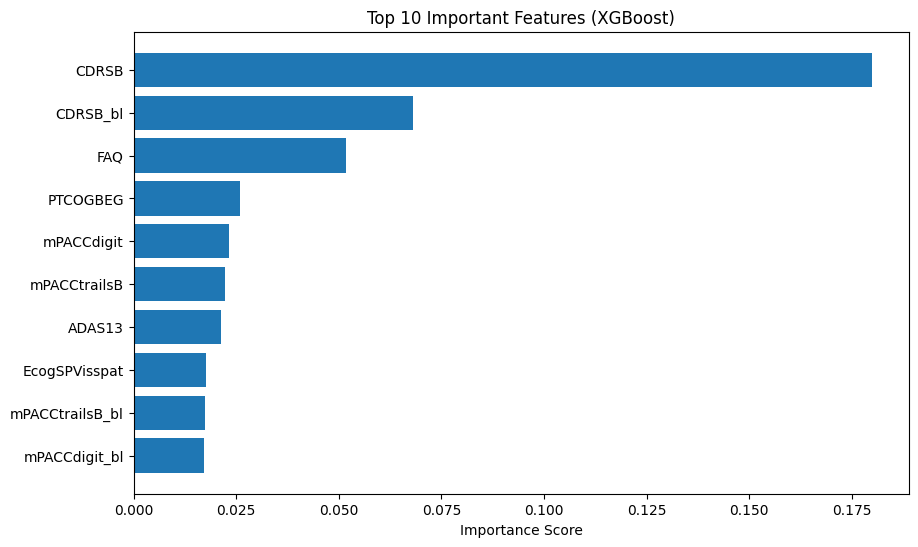

In [28]:
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features (XGBoost)")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Importance Score")
plt.show()